# PX4 Phase 1 Rate Dynamics PINN Training v5 Fix1 Residual Multi-Step

Bugfix version of v5.

Fix1 removes in-place tensor writes inside differentiable reconstruction helpers, which caused PyTorch autograd errors during backpropagation.

Core idea remains unchanged:

```text
current state + action history -> residual around known altitude/yaw kinematics
```

Changes from v5:

- no in-place slice assignment on tensors participating in gradient computation
- yaw sin/cos unit normalization is out-of-place
- rollout feature reconstruction uses cloned tensors with explicit replacement before scaling


In [15]:
# Colab setup
from pathlib import Path
import json
import math
import os
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

try:
    from google.colab import drive
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    drive.mount('/content/drive')

SEED = 7
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)
print('torch:', torch.__version__)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
device: cuda
torch: 2.10.0+cu128


In [16]:
# Dataset path
DATASET_DIR = ''  # e.g. '/content/drive/MyDrive/.../px4_phase1_rate_dynamics_dataset_v2_multirun_...'

def find_latest_dataset_dir():
    patterns = [
        '/content/drive/MyDrive/px4_datasets/processed/px4_phase1_rate_dynamics_dataset_v1_20260505_090024',
        '/content/px4_datasets/processed/px4_phase1_rate_dynamics_dataset_v1_20260505_090024',
        './px4_phase1_rate_dynamics_dataset_v1_20260505_090024',
    ]
    import glob
    matches = []
    for pat in patterns:
        matches.extend(glob.glob(pat, recursive=True))
    matches = sorted(set(matches))
    matches = [Path(m) for m in matches if (Path(m) / 'all_samples.csv').exists()]
    if not matches:
        raise FileNotFoundError('No v2 processed dataset found. Set DATASET_DIR manually.')
    return matches[-1]

DATASET_PATH = Path(DATASET_DIR) if DATASET_DIR else find_latest_dataset_dir()
print('DATASET_PATH:', DATASET_PATH)
print('files:', sorted([p.name for p in DATASET_PATH.iterdir()])[:20])


DATASET_PATH: /content/drive/MyDrive/px4_datasets/processed/px4_phase1_rate_dynamics_dataset_v1_20260505_090024
files: ['all_samples.csv', 'dataset_summary.csv', 'filter_report.csv', 'metadata.json', 'source_summary.csv', 'test.csv', 'train.csv', 'val.csv']


In [17]:
# Load dataset, transform yaw to sin/cos, and rebuild nominal validation split
all_df = pd.read_csv(DATASET_PATH / 'all_samples.csv')
metadata = {}
if (DATASET_PATH / 'metadata.json').exists():
    metadata = json.loads((DATASET_PATH / 'metadata.json').read_text())

raw_state_cols = metadata.get('state_cols') or [c.removeprefix('dx_') for c in all_df.columns if c.startswith('dx_')]
action_cols = metadata.get('action_cols') or [c.removeprefix('u_') for c in all_df.columns if c.startswith('u_')]

# Add yaw sin/cos for current and next states.
yaw_rad = np.deg2rad(all_df['x_yaw_deg'].to_numpy(np.float32))
yaw_next_rad = np.deg2rad(all_df['x_next_yaw_deg'].to_numpy(np.float32))
all_df['x_yaw_sin'] = np.sin(yaw_rad)
all_df['x_yaw_cos'] = np.cos(yaw_rad)
all_df['x_next_yaw_sin'] = np.sin(yaw_next_rad)
all_df['x_next_yaw_cos'] = np.cos(yaw_next_rad)

model_state_cols = []
for c in raw_state_cols:
    if c == 'yaw_deg':
        model_state_cols.extend(['yaw_sin', 'yaw_cos'])
    else:
        model_state_cols.append(c)

feature_cols = (
    [f'x_{c}' for c in model_state_cols]
    + [f'u_{c}' for c in action_cols]
    + [f'prev_u_{c}' for c in action_cols]
    + [f'du_{c}' for c in action_cols]
    + ['dt_s']
)
residual_cols = [f'res_{c}' for c in model_state_cols]
next_cols = [f'x_next_{c}' for c in model_state_cols]

# Nominal-pool validation; keep N11 as hard rollout test.
TEST_SCENARIOS = ['N11_mixed_sequence']
VAL_FRACTION = 0.15
rng = np.random.default_rng(SEED)
test_mask = all_df['scenario'].isin(TEST_SCENARIOS) if 'scenario' in all_df.columns else pd.Series(False, index=all_df.index)
test_df = all_df[test_mask].copy()
pool_df = all_df[~test_mask].copy()
val_indices = []
for _, group in pool_df.groupby([c for c in ['source_run', 'scenario'] if c in pool_df.columns], sort=False):
    n_val = max(1, int(round(len(group) * VAL_FRACTION))) if len(group) >= 20 else 0
    if n_val:
        val_indices.extend(rng.choice(group.index.to_numpy(), size=n_val, replace=False).tolist())
val_df = pool_df.loc[sorted(val_indices)].copy()
train_df = pool_df.drop(index=val_df.index).copy()

required = feature_cols + next_cols
missing = [c for c in required if c not in all_df.columns]
if missing:
    raise ValueError(f'Missing columns: {missing}')

print('train/val/test rows:', len(train_df), len(val_df), len(test_df))
print('model_state_cols:', model_state_cols)
print('action_cols:', action_cols)
print('n_features:', len(feature_cols), 'n_residual_targets:', len(residual_cols))

split_view = pd.concat([train_df.assign(split='train'), val_df.assign(split='val'), test_df.assign(split='test')])
display(split_view.groupby(['split', 'scenario']).size().to_frame('rows').reset_index())


train/val/test rows: 5969 1055 899
model_state_cols: ['relative_altitude_m', 'vel_north_m_s', 'vel_east_m_s', 'vel_down_m_s', 'roll_deg', 'pitch_deg', 'yaw_sin', 'yaw_cos', 'roll_rate_rad_s', 'pitch_rate_rad_s', 'yaw_rate_rad_s']
action_cols: ['ref_roll_rate_rad_s', 'ref_pitch_rate_rad_s', 'ref_yaw_rate_rad_s', 'ref_thrust']
n_features: 24 n_residual_targets: 11


,split,scenario,rows
0,test,N11_mixed_sequence,899
1,train,N00_hover_hold_0p5192,509
2,train,N01_pitch_rate_doublet_5dps,323
3,train,N02_pitch_rate_doublet_10dps,594
4,train,N03_roll_rate_doublet_5dps,303
5,train,N04_roll_rate_doublet_10dps,592
6,train,N05_yaw_rate_doublet_10dps,594
7,train,N06_yaw_rate_doublet_20dps,594
8,train,N07_thrust_step_pm010,594
9,train,N08_thrust_step_pm020,594


In [18]:
# Base kinematics and residual targets
model_state_index = {c: i for i, c in enumerate(model_state_cols)}
action_index = {c: i for i, c in enumerate(action_cols)}

def wrap_angle_np(angle):
    return np.arctan2(np.sin(angle), np.cos(angle))

def base_next_from_arrays(state_arr, dt_arr):
    base = state_arr.copy()
    dt = dt_arr.reshape(-1).astype(np.float32)

    h_i = model_state_index['relative_altitude_m']
    vd_i = model_state_index['vel_down_m_s']
    ys_i = model_state_index['yaw_sin']
    yc_i = model_state_index['yaw_cos']
    yr_i = model_state_index['yaw_rate_rad_s']

    base[:, h_i] = state_arr[:, h_i] - state_arr[:, vd_i] * dt

    yaw = np.arctan2(state_arr[:, ys_i], state_arr[:, yc_i])
    yaw_next = wrap_angle_np(yaw + state_arr[:, yr_i] * dt)
    base[:, ys_i] = np.sin(yaw_next)
    base[:, yc_i] = np.cos(yaw_next)
    return base

def add_residual_targets(df):
    out = df.copy()
    state = out[[f'x_{c}' for c in model_state_cols]].to_numpy(np.float32)
    nxt = out[[f'x_next_{c}' for c in model_state_cols]].to_numpy(np.float32)
    dt = out['dt_s'].to_numpy(np.float32)
    base = base_next_from_arrays(state, dt)
    residual = nxt - base
    for j, c in enumerate(model_state_cols):
        out[f'res_{c}'] = residual[:, j]
    return out

train_df = add_residual_targets(train_df)
val_df = add_residual_targets(val_df)
test_df = add_residual_targets(test_df)

display(pd.concat([
    train_df[residual_cols].agg(['mean', 'std', 'min', 'max']).T.assign(split='train'),
    val_df[residual_cols].agg(['mean', 'std', 'min', 'max']).T.assign(split='val'),
]).reset_index().rename(columns={'index': 'residual'}))


,residual,mean,std,min,max,split
0,res_relative_altitude_m,0.000306,0.020303,-0.937878,0.038600,train
1,res_vel_north_m_s,-0.000313,0.006515,-0.060000,0.160000,train
2,res_vel_east_m_s,-0.002883,0.047578,-3.520000,0.190000,train
3,res_vel_down_m_s,0.000985,0.007761,-0.110000,0.390000,train
4,res_roll_deg,-0.000125,0.040256,-0.726146,0.619929,train
5,res_pitch_deg,0.002127,0.168042,-0.648688,12.628178,train
6,res_yaw_sin,0.000002,0.000117,-0.001144,0.006574,train
7,res_yaw_cos,0.000077,0.001483,-0.007477,0.107883,train
8,res_roll_rate_rad_s,0.000023,0.003625,-0.105426,0.102651,train
9,res_pitch_rate_rad_s,-0.000009,0.003638,-0.111722,0.109920,train


In [19]:
# Scaling and dataloaders
class StandardScaler:
    def __init__(self, mean, std):
        self.mean = np.asarray(mean, dtype=np.float32)
        self.std = np.asarray(std, dtype=np.float32)
        self.std = np.where(self.std < 1e-8, 1.0, self.std)

    @classmethod
    def fit(cls, arr):
        return cls(np.nanmean(arr, axis=0), np.nanstd(arr, axis=0))

    def transform(self, arr):
        return (np.asarray(arr, dtype=np.float32) - self.mean) / self.std

    def inverse_transform(self, arr):
        return np.asarray(arr, dtype=np.float32) * self.std + self.mean

    def to_dict(self, columns):
        return {'columns': list(columns), 'mean': self.mean.tolist(), 'std': self.std.tolist()}

X_train_raw = train_df[feature_cols].to_numpy(np.float32)
Y_train_raw = train_df[residual_cols].to_numpy(np.float32)
X_val_raw = val_df[feature_cols].to_numpy(np.float32)
Y_val_raw = val_df[residual_cols].to_numpy(np.float32)
X_test_raw = test_df[feature_cols].to_numpy(np.float32)
Y_test_raw = test_df[residual_cols].to_numpy(np.float32)

x_scaler = StandardScaler.fit(X_train_raw)
y_scaler = StandardScaler.fit(Y_train_raw)

X_train = x_scaler.transform(X_train_raw)
Y_train = y_scaler.transform(Y_train_raw)
X_val = x_scaler.transform(X_val_raw)
Y_val = y_scaler.transform(Y_val_raw)
X_test = x_scaler.transform(X_test_raw)
Y_test = y_scaler.transform(Y_test_raw)

BATCH_SIZE = 1024
train_loader = DataLoader(TensorDataset(torch.tensor(X_train), torch.tensor(Y_train)), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(TensorDataset(torch.tensor(X_val), torch.tensor(Y_val)), batch_size=BATCH_SIZE, shuffle=False)

x_mean_t = torch.tensor(x_scaler.mean, dtype=torch.float32, device=device)
x_std_t = torch.tensor(x_scaler.std, dtype=torch.float32, device=device)
y_mean_t = torch.tensor(y_scaler.mean, dtype=torch.float32, device=device)
y_std_t = torch.tensor(y_scaler.std, dtype=torch.float32, device=device)
feature_index = {c: i for i, c in enumerate(feature_cols)}
residual_index = {c: i for i, c in enumerate(residual_cols)}
print('batches:', len(train_loader), len(val_loader))


batches: 6 2


In [20]:
# Model
class ResidualDynamicsMLP(nn.Module):
    def __init__(self, n_in, n_out, hidden=512, depth=5, dropout=0.02):
        super().__init__()
        layers = []
        last = n_in
        for _ in range(depth):
            layers += [nn.Linear(last, hidden), nn.SiLU(), nn.LayerNorm(hidden)]
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            last = hidden
        layers.append(nn.Linear(last, n_out))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

MODEL_CONFIG = dict(hidden=512, depth=5, dropout=0.02)
model = ResidualDynamicsMLP(len(feature_cols), len(residual_cols), **MODEL_CONFIG).to(device)
print(model)
print('parameters:', sum(p.numel() for p in model.parameters()))


ResidualDynamicsMLP(
  (net): Sequential(
    (0): Linear(in_features=24, out_features=512, bias=True)
    (1): SiLU()
    (2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (3): Dropout(p=0.02, inplace=False)
    (4): Linear(in_features=512, out_features=512, bias=True)
    (5): SiLU()
    (6): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (7): Dropout(p=0.02, inplace=False)
    (8): Linear(in_features=512, out_features=512, bias=True)
    (9): SiLU()
    (10): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (11): Dropout(p=0.02, inplace=False)
    (12): Linear(in_features=512, out_features=512, bias=True)
    (13): SiLU()
    (14): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (15): Dropout(p=0.02, inplace=False)
    (16): Linear(in_features=512, out_features=512, bias=True)
    (17): SiLU()
    (18): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (19): Dropout(p=0.02, inplace=False)
    (20): Linear(in_features=512, out_featur

In [21]:
# Torch reconstruction helpers
def wrap_angle_t(angle):
    return torch.atan2(torch.sin(angle), torch.cos(angle))

def raw_feature(xb_scaled, name):
    idx = feature_index[name]
    return xb_scaled[:, idx] * x_std_t[idx] + x_mean_t[idx]

def raw_residual(pred_scaled, name):
    idx = residual_index[name]
    return pred_scaled[:, idx] * y_std_t[idx] + y_mean_t[idx]

def current_state_from_scaled(xb_scaled):
    vals = [raw_feature(xb_scaled, f'x_{c}') for c in model_state_cols]
    return torch.stack(vals, dim=1)

def base_next_torch(state, dt):
    h_i = model_state_index['relative_altitude_m']
    vd_i = model_state_index['vel_down_m_s']
    ys_i = model_state_index['yaw_sin']
    yc_i = model_state_index['yaw_cos']
    yr_i = model_state_index['yaw_rate_rad_s']

    yaw = torch.atan2(state[:, ys_i], state[:, yc_i])
    yaw_next = wrap_angle_t(yaw + state[:, yr_i] * dt)

    cols = []
    for j, name in enumerate(model_state_cols):
        if name == 'relative_altitude_m':
            cols.append(state[:, h_i] - state[:, vd_i] * dt)
        elif name == 'yaw_sin':
            cols.append(torch.sin(yaw_next))
        elif name == 'yaw_cos':
            cols.append(torch.cos(yaw_next))
        else:
            cols.append(state[:, j])
    return torch.stack(cols, dim=1)

def normalize_yaw_sincos_out_of_place(state):
    ys_i = model_state_index['yaw_sin']
    yc_i = model_state_index['yaw_cos']
    yaw_norm = torch.sqrt(state[:, ys_i] ** 2 + state[:, yc_i] ** 2).clamp_min(1e-6)
    cols = []
    for j, name in enumerate(model_state_cols):
        if name == 'yaw_sin':
            cols.append(state[:, ys_i] / yaw_norm)
        elif name == 'yaw_cos':
            cols.append(state[:, yc_i] / yaw_norm)
        else:
            cols.append(state[:, j])
    return torch.stack(cols, dim=1)

def pred_next_from_scaled(xb_scaled, pred_scaled):
    state = current_state_from_scaled(xb_scaled)
    dt = raw_feature(xb_scaled, 'dt_s').clamp_min(1e-4)
    base = base_next_torch(state, dt)
    residual = torch.stack([raw_residual(pred_scaled, f'res_{c}') for c in model_state_cols], dim=1)
    pred_next = base + residual
    return normalize_yaw_sincos_out_of_place(pred_next)

def true_next_from_df(df):
    return df[[f'x_next_{c}' for c in model_state_cols]].to_numpy(np.float32)


In [22]:
# Multi-step windows for rollout consistency
def build_windows(df, horizon=5, max_windows=12000):
    windows = []
    group_cols = [c for c in ['source_run', 'scenario'] if c in df.columns]
    for _, g in df.sort_values('time_s').groupby(group_cols, sort=False):
        g = g.sort_values('time_s').reset_index(drop=True)
        if len(g) < horizon:
            continue
        arr = g[feature_cols + [f'x_next_{c}' for c in model_state_cols]].to_numpy(np.float32)
        for i in range(0, len(g) - horizon + 1):
            windows.append(arr[i:i+horizon])
    if len(windows) > max_windows:
        rng = np.random.default_rng(SEED)
        keep = rng.choice(len(windows), size=max_windows, replace=False)
        windows = [windows[i] for i in keep]
    return np.asarray(windows, dtype=np.float32)

ROLLOUT_HORIZON = 5
train_windows = build_windows(train_df, horizon=ROLLOUT_HORIZON, max_windows=16000)
print('train_windows:', train_windows.shape)


train_windows: (5925, 5, 35)


epoch=001 train=0.65517 val=0.24594 val_data=0.24594 unit=0.0000 rollout=603.4389 best_data=0.24594@1 lr=1.00e-03
epoch=020 train=0.09952 val=0.11166 val_data=0.11166 unit=0.0000 rollout=610.0468 best_data=0.11075@19 lr=9.99e-04
epoch=040 train=0.08857 val=0.10489 val_data=0.10489 unit=0.0000 rollout=602.2688 best_data=0.10324@39 lr=9.95e-04
epoch=060 train=0.08305 val=0.10150 val_data=0.10150 unit=0.0000 rollout=598.2110 best_data=0.09831@59 lr=9.88e-04
epoch=080 train=0.07904 val=0.09575 val_data=0.09575 unit=0.0000 rollout=610.6447 best_data=0.09575@80 lr=9.79e-04
epoch=100 train=0.07638 val=0.09573 val_data=0.09573 unit=0.0000 rollout=612.4289 best_data=0.09436@89 lr=9.67e-04
epoch=120 train=0.07431 val=0.09405 val_data=0.09405 unit=0.0000 rollout=603.2433 best_data=0.09385@114 lr=9.52e-04
epoch=140 train=0.07308 val=0.09518 val_data=0.09518 unit=0.0000 rollout=599.4754 best_data=0.09385@114 lr=9.35e-04
epoch=160 train=0.07088 val=0.09472 val_data=0.09472 unit=0.0000 rollout=603.65

,epoch,train_loss,val_loss,train_data,val_data,train_unit_yaw,val_unit_yaw,train_rollout,lr
248,249,0.065548,0.096653,0.065548,0.096653,6.415597e-15,6.044665e-15,595.596047,0.000805
249,250,0.067093,0.095900,0.067093,0.095900,6.466189e-15,6.957257e-15,602.047215,0.000803
250,251,0.066178,0.096581,0.066178,0.096581,6.519161e-15,6.125485e-15,603.875716,0.000802
251,252,0.065716,0.096726,0.065716,0.096726,6.686411e-15,6.485807e-15,601.517120,0.000800
252,253,0.065393,0.095212,0.065393,0.095212,6.355483e-15,6.048032e-15,603.213376,0.000799


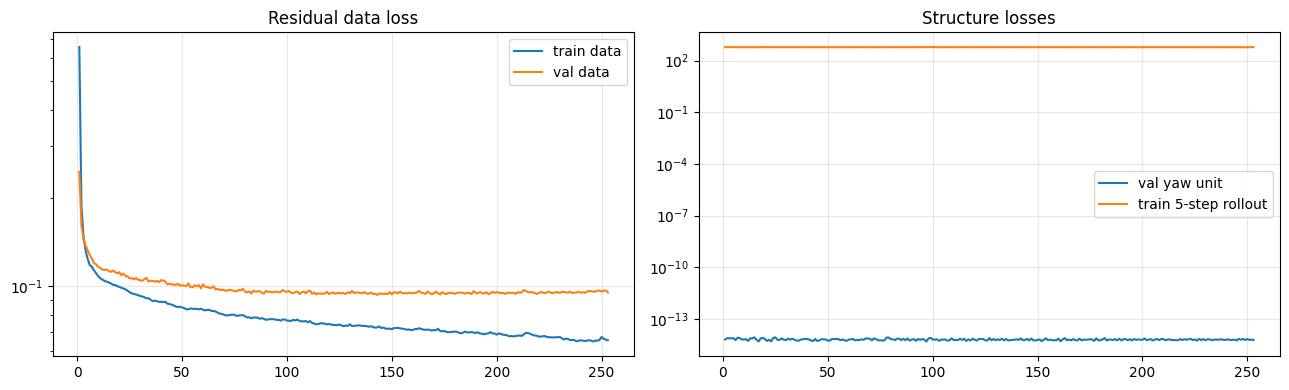

In [23]:
# Training with residual structure + 5-step consistency
EPOCHS = 850
LR = 1.0e-3
WEIGHT_DECAY = 2e-5
PATIENCE = 110
GRAD_CLIP = 2.0

DATA_WEIGHT = 1.0
UNIT_YAW_WEIGHT = 0.04
ROLLOUT_WEIGHT = 0.00
ROLLOUT_BATCH = 256

# Emphasize residuals that dominate rollout drift.
TARGET_DATA_WEIGHTS = {
    'res_relative_altitude_m': 2.0,
    'res_vel_down_m_s': 1.4,
    'res_yaw_sin': 1.8,
    'res_yaw_cos': 1.8,
    'res_yaw_rate_rad_s': 1.3,
}

target_weight_vec = torch.ones(len(residual_cols), dtype=torch.float32, device=device)
for name, value in TARGET_DATA_WEIGHTS.items():
    if name in residual_index:
        target_weight_vec[residual_index[name]] = float(value)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-5)

def smooth_l1_weighted(pred, target, beta=0.5):
    err = pred - target
    abs_err = torch.abs(err)
    loss = torch.where(abs_err < beta, 0.5 * err ** 2 / beta, abs_err - 0.5 * beta)
    return torch.mean(loss * target_weight_vec[None, :])

def unit_yaw_loss(pred_next):
    ys = pred_next[:, model_state_index['yaw_sin']]
    yc = pred_next[:, model_state_index['yaw_cos']]
    return torch.mean((ys ** 2 + yc ** 2 - 1.0) ** 2)

def rollout_loss_sample():
    if len(train_windows) == 0:
        return torch.tensor(0.0, device=device)
    idx = np.random.choice(len(train_windows), size=min(ROLLOUT_BATCH, len(train_windows)), replace=False)
    batch = torch.tensor(train_windows[idx], dtype=torch.float32, device=device)
    n_feat = len(feature_cols)
    feats = batch[:, :, :n_feat]
    true_next = batch[:, :, n_feat:]

    # Start from the first logged feature state. Then recursively replace the
    # state part while keeping the logged command sequence.
    current_state = torch.stack([
        feats[:, 0, feature_index[f'x_{c}']] * x_std_t[feature_index[f'x_{c}']] + x_mean_t[feature_index[f'x_{c}']]
        for c in model_state_cols
    ], dim=1)

    losses = []
    for k in range(batch.shape[1]):
        raw_feat_logged = feats[:, k, :] * x_std_t[None, :] + x_mean_t[None, :]
        raw_cols = []
        state_col_lookup = {f'x_{c}': j for j, c in enumerate(model_state_cols)}
        for col_idx, col_name in enumerate(feature_cols):
            if col_name in state_col_lookup:
                raw_cols.append(current_state[:, state_col_lookup[col_name]])
            else:
                raw_cols.append(raw_feat_logged[:, col_idx])
        raw_feat = torch.stack(raw_cols, dim=1)
        feat_scaled = (raw_feat - x_mean_t[None, :]) / x_std_t[None, :]
        pred_scaled = model(feat_scaled)
        current_state = pred_next_from_scaled(feat_scaled, pred_scaled)
        step_true = true_next[:, k, :]
        losses.append(torch.mean((current_state - step_true) ** 2))
    return torch.stack(losses).mean()

def run_epoch(loader, train_mode):
    model.train(train_mode)
    totals = {'loss': 0.0, 'data': 0.0, 'unit': 0.0, 'rollout': 0.0}
    n = 0
    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)
        if train_mode:
            optimizer.zero_grad(set_to_none=True)
        pred = model(xb)
        data_loss = smooth_l1_weighted(pred, yb)
        pred_next = pred_next_from_scaled(xb, pred)
        unit_loss = unit_yaw_loss(pred_next)
        r_loss = rollout_loss_sample() if train_mode else torch.tensor(0.0, device=device)
        loss = DATA_WEIGHT * data_loss + UNIT_YAW_WEIGHT * unit_loss + ROLLOUT_WEIGHT * r_loss
        if train_mode:
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            optimizer.step()
        batch_n = len(xb)
        totals['loss'] += float(loss.detach().cpu()) * batch_n
        totals['data'] += float(data_loss.detach().cpu()) * batch_n
        totals['unit'] += float(unit_loss.detach().cpu()) * batch_n
        totals['rollout'] += float(r_loss.detach().cpu()) * batch_n
        n += batch_n
    return {k: v / max(n, 1) for k, v in totals.items()}

best_state = None
best_val = float('inf')
best_epoch = -1
history = []
t0 = time.time()

for epoch in range(1, EPOCHS + 1):
    tr = run_epoch(train_loader, True)
    va = run_epoch(val_loader, False)
    scheduler.step()
    row = {
        'epoch': epoch,
        'train_loss': tr['loss'], 'val_loss': va['loss'],
        'train_data': tr['data'], 'val_data': va['data'],
        'train_unit_yaw': tr['unit'], 'val_unit_yaw': va['unit'],
        'train_rollout': tr['rollout'],
        'lr': scheduler.get_last_lr()[0],
    }
    history.append(row)
    monitor = va['data']
    if monitor < best_val:
        best_val = monitor
        best_epoch = epoch
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    if epoch % 20 == 0 or epoch == 1:
        print(
            f"epoch={epoch:03d} train={tr['loss']:.5f} val={va['loss']:.5f} "
            f"val_data={va['data']:.5f} unit={va['unit']:.4f} "
            f"rollout={tr['rollout']:.4f} best_data={best_val:.5f}@{best_epoch} "
            f"lr={scheduler.get_last_lr()[0]:.2e}"
        )
    if epoch - best_epoch >= PATIENCE:
        print(f'early stop at epoch={epoch}, best_epoch={best_epoch}')
        break

model.load_state_dict(best_state)
print('training seconds:', round(time.time() - t0, 1))
hist_df = pd.DataFrame(history)
display(hist_df.tail())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(hist_df['epoch'], hist_df['train_data'], label='train data')
axes[0].plot(hist_df['epoch'], hist_df['val_data'], label='val data')
axes[0].set_yscale('log')
axes[0].grid(True, alpha=0.3)
axes[0].legend()
axes[0].set_title('Residual data loss')
axes[1].plot(hist_df['epoch'], hist_df['val_unit_yaw'], label='val yaw unit')
axes[1].plot(hist_df['epoch'], hist_df['train_rollout'], label='train 5-step rollout')
axes[1].set_yscale('log')
axes[1].grid(True, alpha=0.3)
axes[1].legend()
axes[1].set_title('Structure losses')
plt.tight_layout()
plt.show()


In [24]:
# One-step metrics in physical state units
@torch.no_grad()
def predict_next_df(df):
    x_raw = df[feature_cols].to_numpy(np.float32)
    x_scaled = x_scaler.transform(x_raw)
    preds = []
    model.eval()
    for i in range(0, len(x_scaled), 4096):
        xb = torch.tensor(x_scaled[i:i+4096], dtype=torch.float32, device=device)
        pred_scaled = model(xb)
        pred_next = pred_next_from_scaled(xb, pred_scaled).detach().cpu().numpy()
        preds.append(pred_next)
    return np.concatenate(preds, axis=0) if preds else np.zeros((0, len(model_state_cols)), dtype=np.float32)

def one_step_metrics(df, split):
    pred_next = predict_next_df(df)
    true_next = df[[f'x_next_{c}' for c in model_state_cols]].to_numpy(np.float32)
    rows = []
    for j, col in enumerate(model_state_cols):
        err = pred_next[:, j] - true_next[:, j]
        rows.append({'split': split, 'state': col, 'rmse': float(np.sqrt(np.mean(err ** 2))), 'mae': float(np.mean(np.abs(err))), 'std_true': float(np.std(true_next[:, j]))})
    # Add yaw angle error for readability.
    ys_i, yc_i = model_state_index['yaw_sin'], model_state_index['yaw_cos']
    pred_yaw = np.arctan2(pred_next[:, ys_i], pred_next[:, yc_i])
    true_yaw = np.arctan2(true_next[:, ys_i], true_next[:, yc_i])
    yaw_err_deg = np.rad2deg(wrap_angle_np(pred_yaw - true_yaw))
    rows.append({'split': split, 'state': 'yaw_angle_deg_wrapped', 'rmse': float(np.sqrt(np.mean(yaw_err_deg ** 2))), 'mae': float(np.mean(np.abs(yaw_err_deg))), 'std_true': float(np.std(np.rad2deg(true_yaw)))})
    return pd.DataFrame(rows)

metrics_df = pd.concat([one_step_metrics(train_df, 'train'), one_step_metrics(val_df, 'val'), one_step_metrics(test_df, 'test')], ignore_index=True)
display(metrics_df)


,split,state,rmse,mae,std_true
0,train,relative_altitude_m,0.019868,0.003250,3.599180
1,train,vel_north_m_s,0.004055,0.001439,0.390371
2,train,vel_east_m_s,0.045628,0.002936,2.778173
3,train,vel_down_m_s,0.006983,0.002345,0.342536
4,train,roll_deg,0.006820,0.001528,0.635218
5,train,pitch_deg,0.160201,0.004083,2.283509
6,train,yaw_sin,0.000090,0.000008,0.008230
7,train,yaw_cos,0.001408,0.000094,0.076080
8,train,roll_rate_rad_s,0.001298,0.000301,0.014208
9,train,pitch_rate_rad_s,0.001048,0.000308,0.013590


In [25]:
# Recursive rollout sanity
def make_raw_feature_from_state(row, state_vec, prev_action_vec=None):
    raw = row[feature_cols].to_numpy(np.float32).copy()
    for j, c in enumerate(model_state_cols):
        raw[feature_index[f'x_{c}']] = state_vec[j]
    if prev_action_vec is not None:
        for j, c in enumerate(action_cols):
            raw[feature_index[f'prev_u_{c}']] = prev_action_vec[j]
            u = raw[feature_index[f'u_{c}']]
            raw[feature_index[f'du_{c}']] = u - prev_action_vec[j]
    return raw

@torch.no_grad()
def rollout_scenario(df, scenario, max_steps=None):
    sdf = df[df['scenario'].eq(scenario)].sort_values('time_s').reset_index(drop=True)
    if max_steps is not None:
        sdf = sdf.iloc[:max_steps].copy()
    if len(sdf) < 2:
        return None
    true_next = sdf[[f'x_next_{c}' for c in model_state_cols]].to_numpy(np.float32)
    state = sdf.iloc[0][[f'x_{c}' for c in model_state_cols]].to_numpy(np.float32)
    pred_states = []
    prev_action = sdf.iloc[0][[f'prev_u_{c}' for c in action_cols]].to_numpy(np.float32)
    model.eval()
    for _, row in sdf.iterrows():
        raw_feat = make_raw_feature_from_state(row, state, prev_action)
        feat_scaled = x_scaler.transform(raw_feat[None, :])
        xb = torch.tensor(feat_scaled, dtype=torch.float32, device=device)
        pred_scaled = model(xb)
        state = pred_next_from_scaled(xb, pred_scaled).detach().cpu().numpy()[0]
        pred_states.append(state.copy())
        prev_action = row[[f'u_{c}' for c in action_cols]].to_numpy(np.float32)
    pred_states = np.asarray(pred_states)
    err = pred_states - true_next
    rows = []
    for j, col in enumerate(model_state_cols):
        rows.append({'scenario': scenario, 'state': col, 'rollout_rmse': float(np.sqrt(np.mean(err[:, j] ** 2))), 'rollout_max_abs': float(np.max(np.abs(err[:, j]))), 'steps': int(len(sdf))})
    ys_i, yc_i = model_state_index['yaw_sin'], model_state_index['yaw_cos']
    yaw_err_deg = np.rad2deg(wrap_angle_np(np.arctan2(pred_states[:, ys_i], pred_states[:, yc_i]) - np.arctan2(true_next[:, ys_i], true_next[:, yc_i])))
    rows.append({'scenario': scenario, 'state': 'yaw_angle_deg_wrapped', 'rollout_rmse': float(np.sqrt(np.mean(yaw_err_deg ** 2))), 'rollout_max_abs': float(np.max(np.abs(yaw_err_deg))), 'steps': int(len(sdf))})
    return pd.DataFrame(rows), sdf, pred_states, true_next

scenario_metrics = []
for scenario in sorted(test_df['scenario'].unique()):
    result = rollout_scenario(test_df, scenario)
    if result is not None:
        scenario_metrics.append(result[0])
rollout_metrics_df = pd.concat(scenario_metrics, ignore_index=True) if scenario_metrics else pd.DataFrame()
display(rollout_metrics_df)


,scenario,state,rollout_rmse,rollout_max_abs,steps
0,N11_mixed_sequence,relative_altitude_m,15.002836,24.760391,899
1,N11_mixed_sequence,vel_north_m_s,1.155816,2.146348,899
2,N11_mixed_sequence,vel_east_m_s,0.609792,1.382559,899
3,N11_mixed_sequence,vel_down_m_s,0.607134,1.176697,899
4,N11_mixed_sequence,roll_deg,0.765845,1.853812,899
5,N11_mixed_sequence,pitch_deg,4.526104,6.700961,899
6,N11_mixed_sequence,yaw_sin,0.011595,0.020860,899
7,N11_mixed_sequence,yaw_cos,0.218635,0.295792,899
8,N11_mixed_sequence,roll_rate_rad_s,0.006837,0.057056,899
9,N11_mixed_sequence,pitch_rate_rad_s,0.012516,0.049023,899


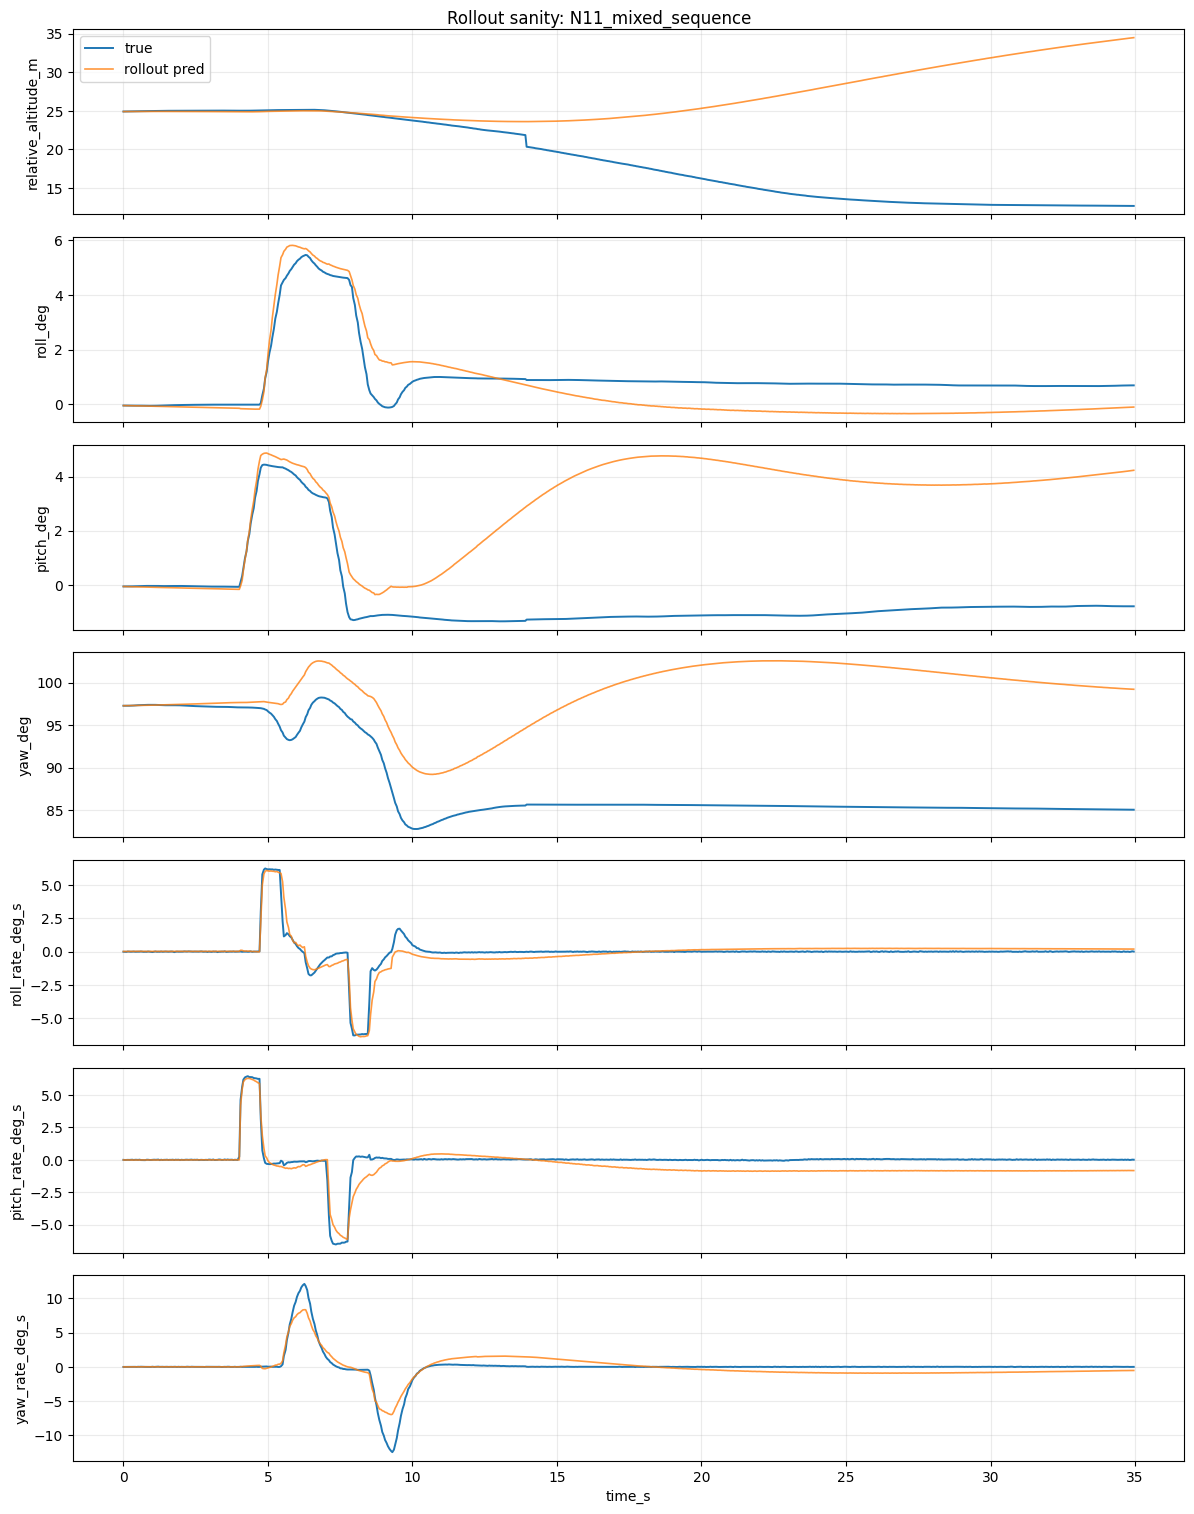

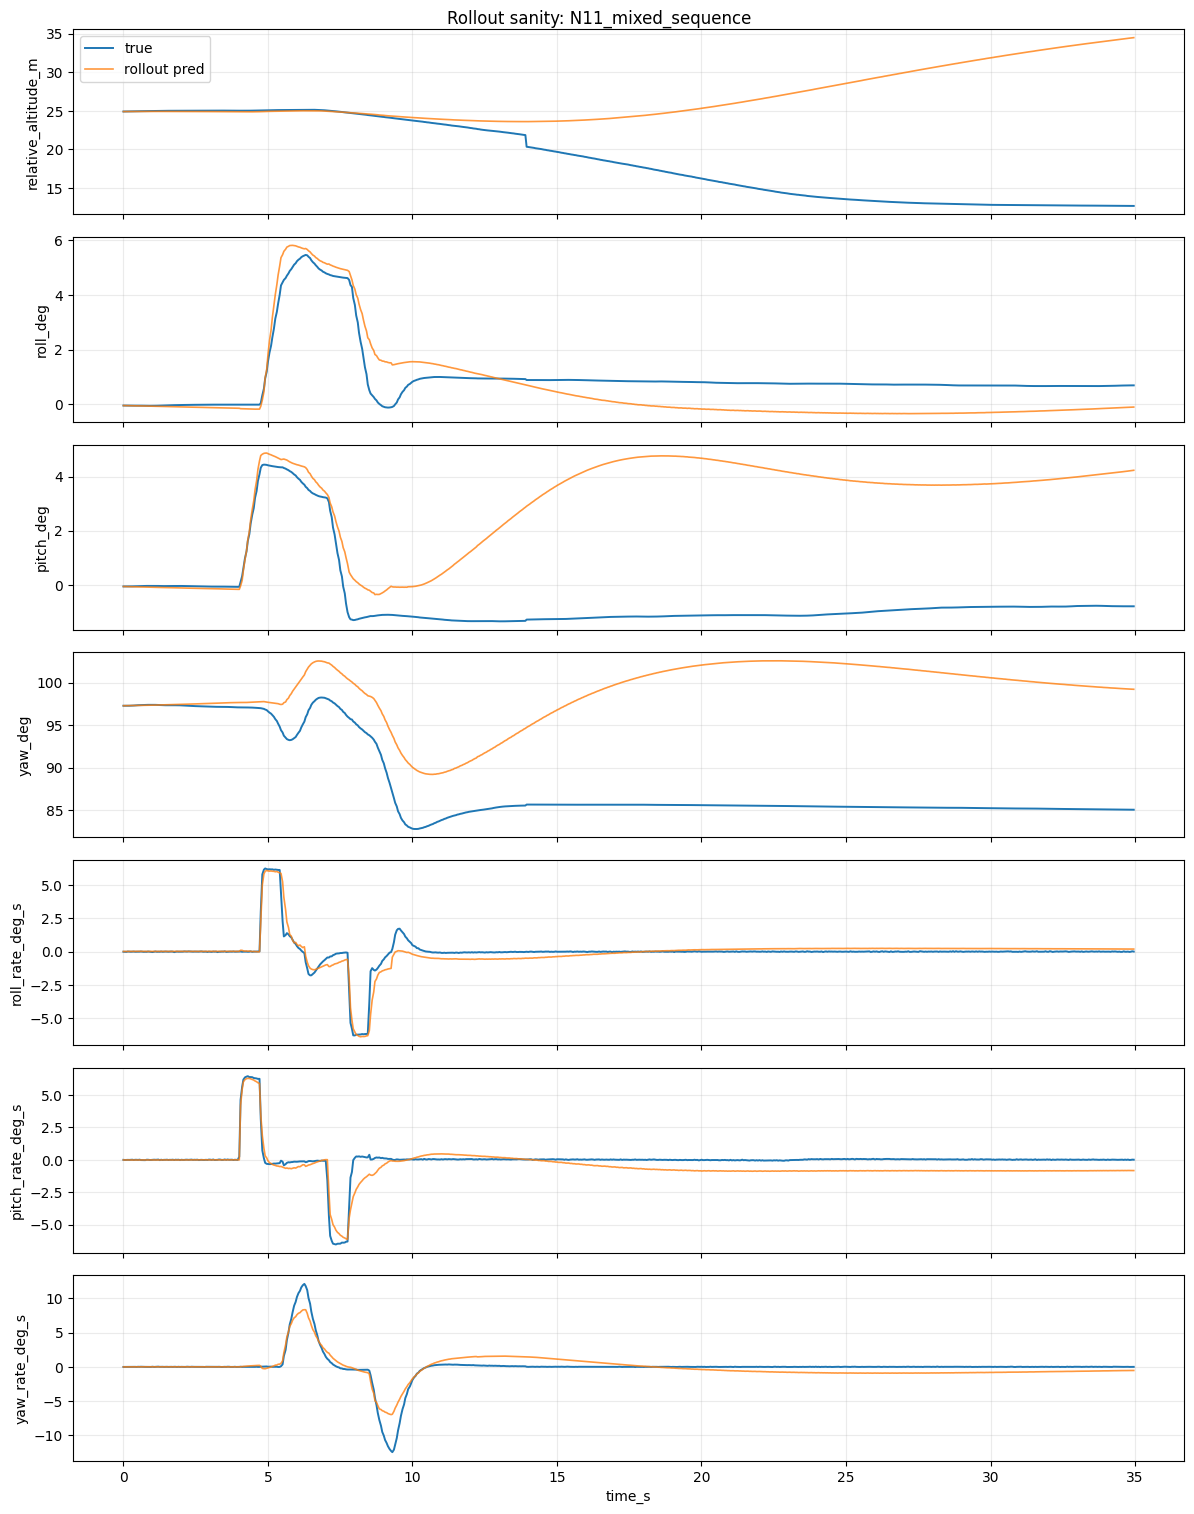

In [26]:
# Plot selected rollouts
def plot_rollout(df, scenario, max_steps=700):
    result = rollout_scenario(df, scenario, max_steps=max_steps)
    if result is None:
        print('not enough rows for', scenario)
        return
    _, sdf, pred_states, true_next = result
    t = sdf['time_s'].to_numpy()
    states_to_plot = ['relative_altitude_m', 'roll_deg', 'pitch_deg', 'yaw_angle_deg_wrapped', 'roll_rate_rad_s', 'pitch_rate_rad_s', 'yaw_rate_rad_s']
    fig, axes = plt.subplots(len(states_to_plot), 1, figsize=(12, 2.2 * len(states_to_plot)), sharex=True)
    ys_i, yc_i = model_state_index['yaw_sin'], model_state_index['yaw_cos']
    for ax, state_name in zip(axes, states_to_plot):
        if state_name == 'yaw_angle_deg_wrapped':
            y_true = np.rad2deg(np.arctan2(true_next[:, ys_i], true_next[:, yc_i]))
            y_pred = np.rad2deg(np.arctan2(pred_states[:, ys_i], pred_states[:, yc_i]))
            label = 'yaw_deg'
        else:
            j = model_state_index[state_name]
            y_true = true_next[:, j]
            y_pred = pred_states[:, j]
            label = state_name
            if state_name.endswith('_rad_s'):
                y_true = np.rad2deg(y_true)
                y_pred = np.rad2deg(y_pred)
                label = state_name.replace('_rad_s', '_deg_s')
        ax.plot(t, y_true, label='true', lw=1.4)
        ax.plot(t, y_pred, label='rollout pred', lw=1.2, alpha=0.8)
        ax.set_ylabel(label)
        ax.grid(True, alpha=0.25)
    axes[0].legend(loc='best')
    axes[-1].set_xlabel('time_s')
    fig.suptitle(f'Rollout sanity: {scenario}')
    plt.tight_layout()
    plt.show()

for scenario in sorted(test_df['scenario'].unique())[:4]:
    plot_rollout(test_df, scenario)
if 'N11_mixed_sequence' in set(test_df['scenario']):
    plot_rollout(test_df, 'N11_mixed_sequence')


In [27]:
# Save checkpoint
SAVE_ROOT = Path('/content/drive/MyDrive/PX4_Phase1_Models') if IN_COLAB else DATASET_PATH / 'models'
SAVE_ROOT.mkdir(parents=True, exist_ok=True)
stamp = time.strftime('%Y%m%d_%H%M%S')
ckpt_path = SAVE_ROOT / f'px4_phase1_rate_dynamics_residual_v5_fix1_multistep_{stamp}.pt'
checkpoint = {
    'model_version': 'px4_phase1_rate_dynamics_residual_v5_fix1_multistep',
    'state_dict': model.state_dict(),
    'model_config': {'n_in': len(feature_cols), 'n_out': len(residual_cols), **MODEL_CONFIG},
    'training_contract': 'features -> residual around altitude/yaw base kinematics',
    'raw_state_cols': raw_state_cols,
    'model_state_cols': model_state_cols,
    'action_cols': action_cols,
    'feature_cols': feature_cols,
    'residual_cols': residual_cols,
    'x_scaler': x_scaler.to_dict(feature_cols),
    'y_scaler': y_scaler.to_dict(residual_cols),
    'dataset_path': str(DATASET_PATH),
    'metadata': metadata,
    'loss_config': {
        'data_weight': DATA_WEIGHT,
        'unit_yaw_weight': UNIT_YAW_WEIGHT,
        'rollout_weight': ROLLOUT_WEIGHT,
        'rollout_horizon': ROLLOUT_HORIZON,
        'target_data_weights': TARGET_DATA_WEIGHTS,
        'validation_policy': 'nominal_pool_random_validation_with_N11_mixed_test',
    },
    'history': hist_df.to_dict(orient='records'),
    'one_step_metrics': metrics_df.to_dict(orient='records'),
    'rollout_metrics': rollout_metrics_df.to_dict(orient='records'),
}
torch.save(checkpoint, ckpt_path)
print('saved:', ckpt_path)


saved: /content/drive/MyDrive/PX4_Phase1_Models/px4_phase1_rate_dynamics_residual_v5_fix1_multistep_20260506_104511.pt


In [28]:
# Minimal load check
loaded = torch.load(ckpt_path, map_location='cpu')
print('loaded keys:', sorted(loaded.keys()))
print('feature count:', len(loaded['feature_cols']))
print('residual count:', len(loaded['residual_cols']))


loaded keys: ['action_cols', 'dataset_path', 'feature_cols', 'history', 'loss_config', 'metadata', 'model_config', 'model_state_cols', 'model_version', 'one_step_metrics', 'raw_state_cols', 'residual_cols', 'rollout_metrics', 'state_dict', 'training_contract', 'x_scaler', 'y_scaler']
feature count: 24
residual count: 11
